In [ ]:
import numpy as np
import pandas as pd
df = pd.read_csv("/content/instructors_dataset.csv")

In [ ]:
df.sample(5)

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
554,B_0102,I_095,C_06,0.519752,26.429947,61.283406,0.362767,0.664601,0.458211,0.178210,4.271796,0.520099
1992,B_1045,I_098,C_17,0.614077,26.232903,64.151608,0.384666,0.949057,0.628445,0.225241,3.994623,0.924617
527,B_0335,I_023,C_20,0.457411,16.188823,55.190909,0.586364,0.843535,0.659021,0.197610,4.802842,0.552842
1065,B_1356,I_060,C_05,0.549100,33.173537,82.503907,0.481204,0.785713,0.750583,0.346927,4.576982,0.656200
1692,B_0955,I_065,C_13,0.516198,24.939985,71.601886,0.523029,0.586554,0.802647,0.152842,3.737221,0.587098


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [ ]:
df.nunique()

,0
batch_id,2000
instructor_id,120
course_id,25
completion_rate,1893
avg_score_improvement,1966
avg_quiz_score,1964
dropout_rate,1907
avg_watch_time,1852
assignment_submission_rate,1876
forum_activity_rate,1987


## About Data
 There are no null values and datatypes are perfect. There are 120 instructors to classify. completion_rate - 1893, avg_score_improvement - 1966 this all show that data is countinous so it is ML friendly. avg_score_improvement- 10–40, avg_quiz_score- 50–90, Others- 0–1. so we must normalize before combining.

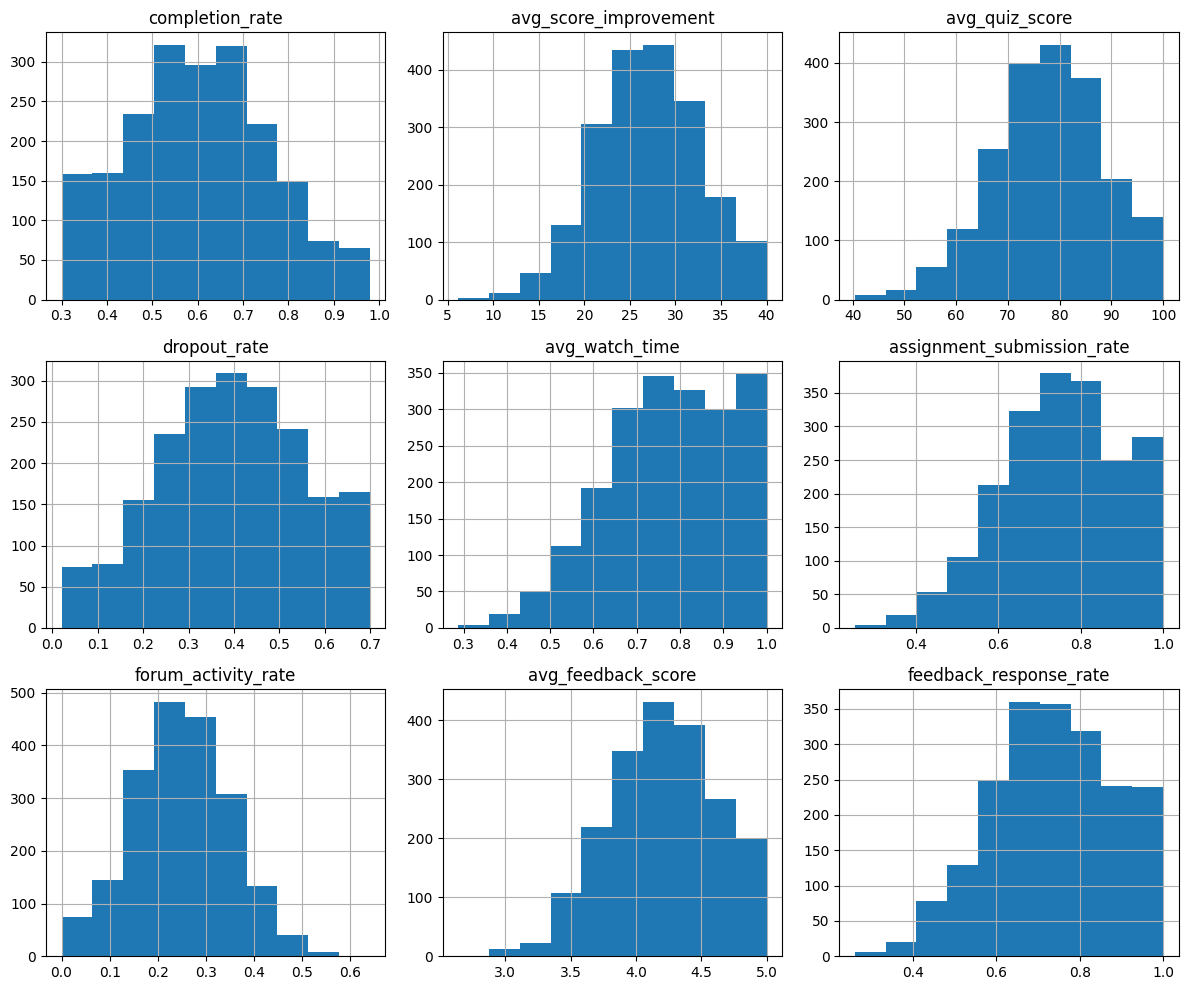

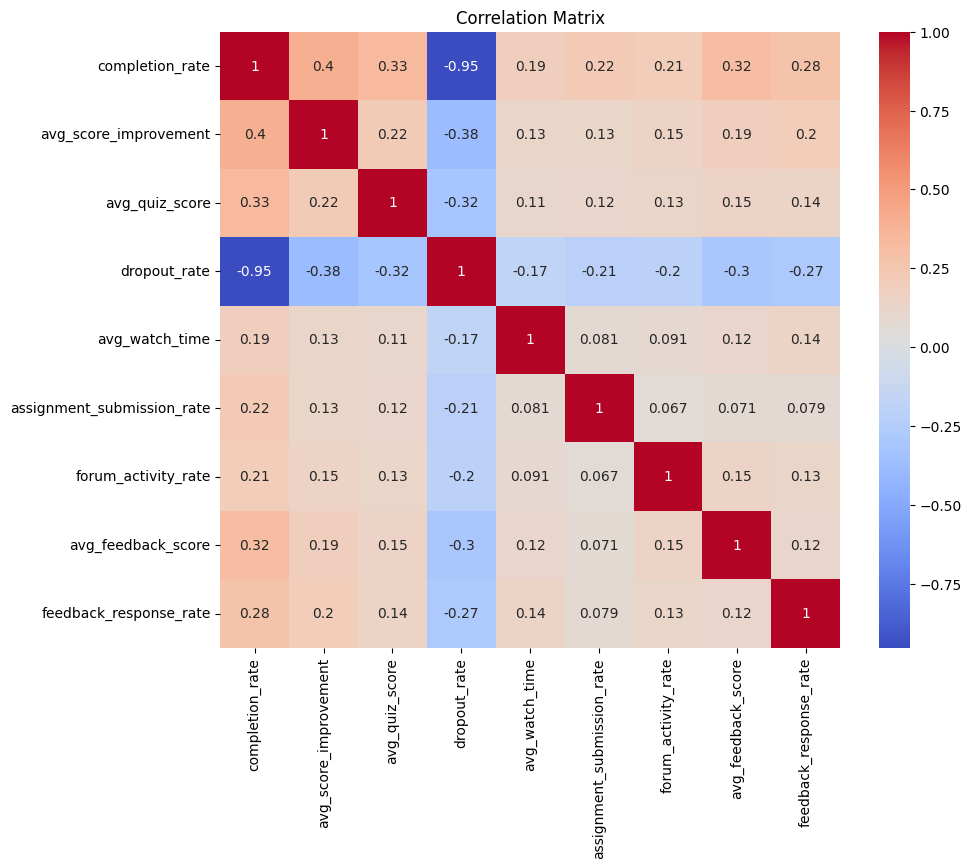

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

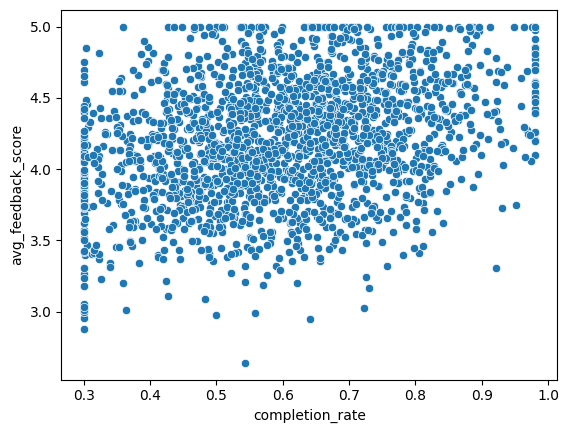

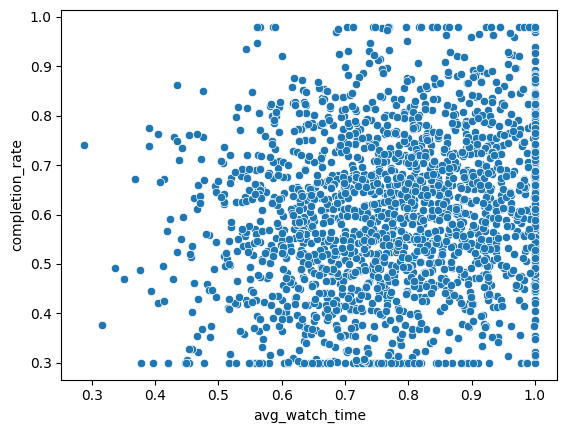

In [ ]:
sns.scatterplot(data=df, x="completion_rate", y="avg_feedback_score")
plt.show()
sns.scatterplot(data=df, x="avg_watch_time", y="completion_rate")
plt.show()

## Data Analysis
# Learning Metrics
completion_rate and dropout_rate are highly negatively correlated (this is expected) - so we better don't need both of them (so combine)
completion_rate - avg_score_improvement - 0.40
completion_rate - avg_quiz_score - 0.33 (this means Students who complete courses tend to improve and score better)
Dropout has negative correlation with almost everything, so Dropout is one of the strongest indicators of poor instructor performance
# Engagement Metrics
avg_watch_time - completion - 0.19
assignment_submission - completion - 0.22
forum_activity - completion - 0.21
This has some confusion to weight
# Feedback
avg_feedback_score - completion - 0.32
feedback_response_rate - completion - 0.28
Feedback is useful, but not as strong as learning outcomes


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
df["avg_feedback_score"] = df["avg_feedback_score"] / 5
features = ["completion_rate","dropout_rate","avg_score_improvement","avg_quiz_score","avg_watch_time","assignment_submission_rate","forum_activity_rate","avg_feedback_score","feedback_response_rate"]
X = df[features].copy()
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


## Execution
Instead of manually assigning weights, we’ll learn them from data.
Its better to Create a proxy target (effectiveness) using unsupervised learning then training a model to learn feature importance (implicit weights)

In [ ]:
pca = PCA(n_components=1)
df["effectiveness_score"] = pca.fit_transform(X_scaled)
df["effectiveness_score"] = MinMaxScaler().fit_transform(df[["effectiveness_score"]])

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["tier"] = kmeans.fit_predict(df[["effectiveness_score"]])
cluster_order = (df.groupby("tier")["effectiveness_score"].mean().sort_values().index)
mapping = {cluster_order[0]: "Low",cluster_order[1]: "Medium",cluster_order[2]: "High"}
df["tier"] = df["tier"].map(mapping)
print("Tier Distribution:\n", df["tier"].value_counts())

Tier Distribution:
 tier
Medium    911
High      630
Low       459
Name: count, dtype: int64


In [ ]:
agg_df = df.groupby("instructor_id").agg({"effectiveness_score": ["mean", "std"],"completion_rate": "mean","dropout_rate": "mean","avg_score_improvement": "mean","avg_quiz_score": "mean","avg_watch_time": "mean",
    "assignment_submission_rate": "mean","forum_activity_rate": "mean","avg_feedback_score": "mean","feedback_response_rate": "mean","batch_id": "count"}).reset_index()

agg_df.columns = ["instructor_id","effectiveness_mean","effectiveness_std","completion_rate","dropout_rate","avg_score_improvement","avg_quiz_score","avg_watch_time","assignment_submission_rate","forum_activity_rate","avg_feedback_score",
    "feedback_response_rate","num_batches"]


In [ ]:
agg_df["experience_weight"] = np.log1p(agg_df["num_batches"])
agg_df["adjusted_effectiveness"] = (agg_df["effectiveness_mean"] * agg_df["experience_weight"])

In [ ]:
agg_df["tier"] = pd.qcut(agg_df["effectiveness_mean"],q=3,labels=["Low", "Medium", "High"])

In [ ]:
X = agg_df.drop(["instructor_id", "tier"], axis=1)
y = agg_df["tier"]
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         6
         Low       1.00      1.00      1.00         6
      Medium       1.00      1.00      1.00        12

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24


Confusion Matrix:

[[ 6  0  0]
 [ 0  6  0]
 [ 0  0 12]]


## Explanation 1
Accuracy = 1.00, Perfect confusion matrix but, effectiveness_score - from features, tier - from that score, then used same features to predict tier. So the model is basically learning reverse engineer the formula I already used. Only 24 test samples easy to overfit. Instructor effectiveness is primarily driven by retention (dropout & completion) rather than engagement. Instructor effectiveness is primarily driven by retention (dropout & completion) rather than engagement. So this time We will NOT use effectiveness_score as input (to avoid leakage). We’ll predict effectiveness tier using only raw aggregated features.

In [ ]:
features = ["completion_rate","dropout_rate","avg_score_improvement",
    "avg_quiz_score","avg_watch_time","assignment_submission_rate",
    "forum_activity_rate","avg_feedback_score","feedback_response_rate"]
X = df[features]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=1)
score = pca.fit_transform(X_scaled)

In [ ]:
df["effectiveness_score"] = score
pca_weights = pd.Series(pca.components_[0], index=features)
if pca_weights["dropout_rate"] > 0:
    df["effectiveness_score"] *= -1

df["effectiveness_score"] = MinMaxScaler().fit_transform(df[["effectiveness_score"]])
df["tier"] = pd.qcut(df["effectiveness_score"],q=3,labels=["Low", "Medium", "High"])

In [ ]:
agg_df = df.groupby("instructor_id").agg({"effectiveness_score": ["mean", "std"],"completion_rate": "mean","dropout_rate": "mean","avg_score_improvement": "mean","avg_quiz_score": "mean","avg_watch_time": "mean",
    "assignment_submission_rate": "mean","forum_activity_rate": "mean","avg_feedback_score": "mean","feedback_response_rate": "mean","batch_id": "count"}).reset_index()

agg_df.columns = ["instructor_id","effectiveness_mean","effectiveness_std","completion_rate","dropout_rate","avg_score_improvement","avg_quiz_score","avg_watch_time","assignment_submission_rate","forum_activity_rate","avg_feedback_score",
    "feedback_response_rate","num_batches"]


In [ ]:
agg_df["experience_weight"] = np.log1p(agg_df["num_batches"])
agg_df["final_score"] = (agg_df["effectiveness_mean"] * agg_df["experience_weight"])

agg_df["tier"] = pd.qcut(agg_df["final_score"],q=3,labels=["Low", "Medium", "High"])


In [73]:
X = agg_df.drop(["instructor_id","tier","effectiveness_mean","final_score"], axis=1)
y = agg_df["tier"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [74]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         8
         Low       0.88      0.88      0.88         8
      Medium       0.88      0.88      0.88         8

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.92      0.92      0.92        24


Confusion Matrix:

[[8 0 0]
 [0 7 1]
 [0 1 7]]


## Explanation 2
good, Balanced across classes (no major bias), no obvious leakage now.
Low tier(for low performers)
The model correctly identifies all low-performing instructors.
Precision = 0.88
Recall = 0.88
The model correctly identifies all low-performing instructors
High Tier(for high performers)
Precision = 1.00
Recall = 1.00
it is always correct, But it misses a few high performers
The model achieves an accuracy of 92% better then 100% with overfitting

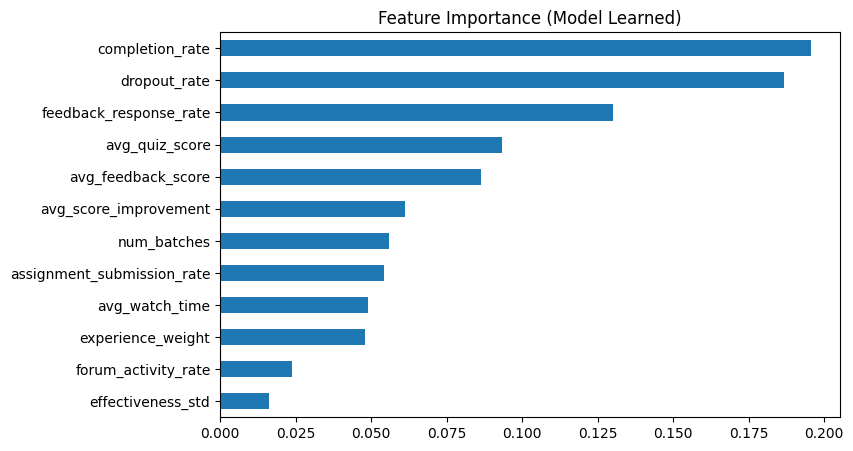

In [75]:
importance = pd.Series(model.feature_importances_,index=X.columns).sort_values()
plt.figure(figsize=(8,5))
importance.plot(kind="barh")
plt.title("Feature Importance (Model Learned)")
plt.show()


In [76]:
print("\nTop Instructors:\n",agg_df.sort_values("final_score", ascending=False).head(5))

print("\nLow Performing Instructors:\n",agg_df.sort_values("final_score").head(5))


Top Instructors:
     instructor_id  effectiveness_mean  effectiveness_std  completion_rate  \
36          I_037            0.873907           0.057732         0.923555   
9           I_010            0.907711           0.077737         0.940783   
50          I_051            0.721876           0.104463         0.793270   
4           I_005            0.789220           0.096725         0.859747   
104         I_105            0.813569           0.072005         0.863880   

     dropout_rate  avg_score_improvement  avg_quiz_score  avg_watch_time  \
36       0.086773               0.827824        0.786673        0.903739   
9        0.068522               0.848016        0.843264        0.900853   
50       0.210509               0.744491        0.733904        0.796738   
4        0.145733               0.780993        0.762270        0.847026   
104      0.141051               0.818896        0.769730        0.870686   

     assignment_submission_rate  forum_activity_rate  avg_fee

## Final
so, Top and low performance metrics are give in the final result,

5 Top performers are - I_037, I_010, I_051, I_005, I_105

5 Low performers are - I_050, I_075, I_044, I_083, I_067
